In [1]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 34.0 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


# 1 FDM

### 1.1 FMD code

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # ---------------------------
        # Physical parameters
        # ---------------------------
        self.L = params['L']                      # latent heat [MJ/m^3]
        self.C_i = params['C_i']                  # ice volumetric heat capacity
        self.C_l = params['C_l']                  # liquid water volumetric heat capacity
        self.C_f = params['C_f']                  # soil skeleton volumetric heat capacity

        self.lambda_i = params['lambda_i']        # ice thermal conductivity [MJ/(day·m·K)]
        self.lambda_l = params['lambda_l']        # liquid water thermal conductivity
        self.lambda_f = params['lambda_f']        # soil skeleton thermal conductivity

        self.eta = params['eta']                  # porosity / max unfrozen water content upper bound
        self.theta_r = params['theta_r']          # residual unfrozen water content
        self.T_f = params['T_f']                  # freezing transition center temperature
        self.k = params['k']                      # logistic steepness

        # ---------------------------
        # Grid parameters
        # ---------------------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature(self, t):
        """
        Surface temperature boundary condition [degC]
        You can modify this function directly if needed.
        """
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        """
        Initial temperature profile [degC]
        Linear profile from surface initial temperature to bottom temperature.
        """
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        """
        Logistic unfrozen water content:
            theta(T) = theta_r + (eta - theta_r)/(1 + exp(-k*(T - T_f)))
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        """
        Derivative of logistic unfrozen water content:
            dtheta/dT = (eta - theta_r) * k * exp(-k*(T-T_f)) / (1+exp(-k*(T-T_f)))^2
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        """
        Sensible heat capacity only:
            C_eff = (1-eta) C_f + theta C_l + (eta-theta) C_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity:
            C_app = C_eff + L * dtheta/dT
        """
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        """
        Effective conductivity:
            lambda_eff = (1-eta) lambda_f + theta lambda_l + (eta-theta) lambda_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # =========================================================
    # Diagnostics
    # =========================================================
    def print_diagnostics(self, T):
        theta = self.theta_unfrozen(T)
        dth = self.dtheta_dT(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range       : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  theta range   : [{np.min(theta):.6f}, {np.max(theta):.6f}]")
        print(f"  dtheta/dT     : [{np.min(dth):.6f}, {np.max(dth):.6f}]")
        print(f"  C_eff range   : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range   : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range  : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # =========================================================
    # Implicit solver
    # =========================================================
    def solve_implicit(self, verbose=True):
        """
        Solve:
            C_app(T) * dT/dt = d/dx( lambda(T) dT/dx )

        Backward-Euler-like implicit discretization with coefficients evaluated at old time step.
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T_old = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...")
            self.print_diagnostics(T_old)

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # ---------------------------
            # Top boundary: Dirichlet
            # ---------------------------
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_new)

            # ---------------------------
            # Bottom boundary: Dirichlet
            # ---------------------------
            A[-1, -1] = 1.0
            b[-1] = 1.0

            # ---------------------------
            # Interior nodes
            # ---------------------------
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T_old)

        return self.T_field

    # =========================================================
    # Post-processing
    # =========================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")
        t_start = self.T_total - 365.0
        mask = self.t >= t_start
        return self.t[mask] - t_start, self.T_field[:, mask]

    def save_results(self, filename="fdm_logistic_ahc_3years.npz"):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'theta_r': self.theta_r,
                'T_f': self.T_f,
                'k': self.k
            }
        )
        print(f"Results saved to {filename}")

    def save_last_year_results(self, filename="fdm_logistic_ahc_last_year.npz"):
        t_last, T_last = self.get_last_year_data()
        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last
        )
        print(f"Last-year results saved to {filename}")

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self):
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (All Years)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 100, 365, 730, 900, 1094]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...
Diagnostics:
  T range       : [-11.926392, 1.000000]
  theta range   : [0.171456, 0.259736]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.280219]
  C_app range   : [3.876987, 4.774665]
  lambda range  : [0.140898, 0.154207]
  dx = 0.050000, dt = 0.024335
  Progress: 10.0%   elapsed: 0.8s
  Progress: 20.0%   elapsed: 1.6s
  Progress: 30.0%   elapsed: 4.3s
  Progress: 40.0%   elapsed: 5.1s
  Progress: 50.0%   elapsed: 5.9s
  Progress: 60.0%   elapsed: 6.7s
  Progress: 70.0%   elapsed: 7.5s
  Progress: 80.0%   elapsed: 8.3s
  Progress: 90.0%   elapsed: 9.1s
Solution completed in 9.9s
Diagnostics:
  T range       : [-11.926392, 2.393861]
  theta range   : [0.171456, 0.270083]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.306167]
  C_app range   : [3.876987, 4.774924]
  lambda range  : [0.139338, 0.154207]
  dx = 0.050000, dt = 0.024335
All-years T min = -12.079999989780223
A

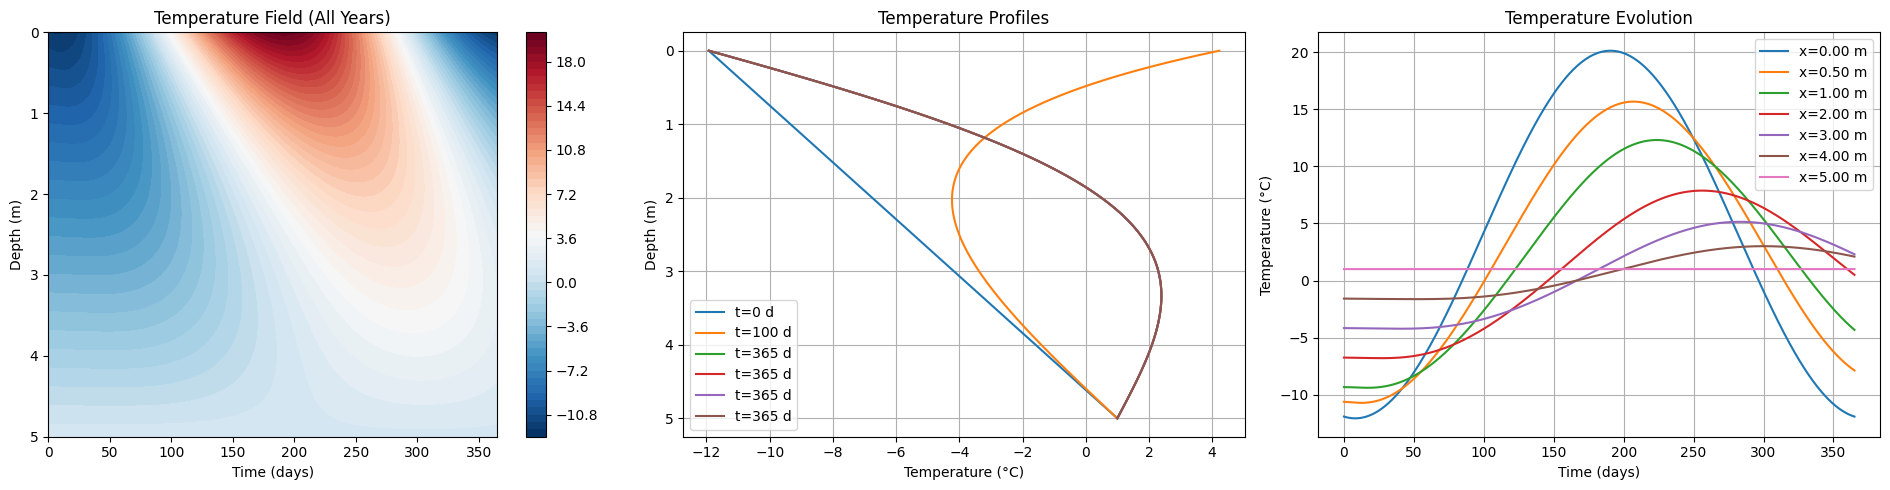

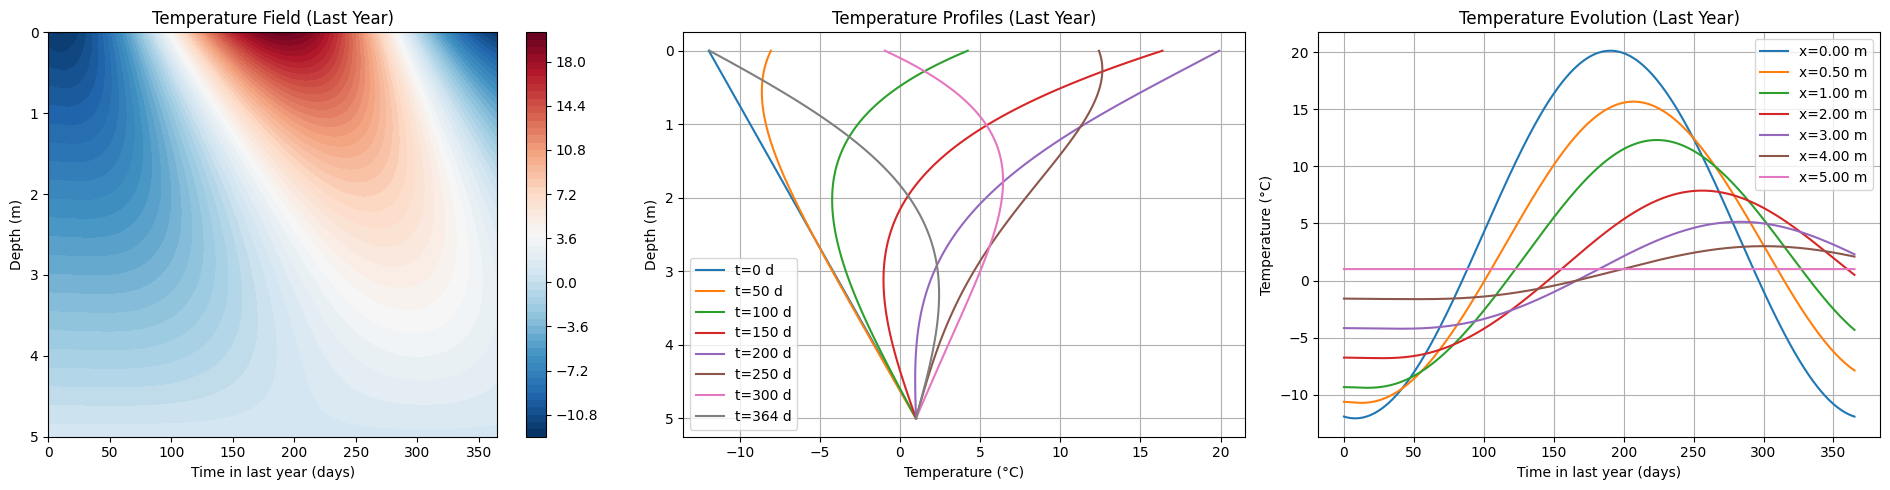

In [3]:
if __name__ == "__main__":
    params = {
        # latent heat and volumetric heat capacities [MJ/m^3/K or MJ/m^3]
        # volumetric latent heat [MJ/m^3]
        'L': 334.0,
        # volumetric heat capacities [MJ/(m^3·K)]
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,

        # conductivities converted to MJ/(day·m·K)
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,

        # logistic unfrozen water parameters
        'eta': 0.40,       # porosity [-]
        'theta_r': 0.1,    # residual unfrozen water content
        'T_f': -0.3,        # transition center [degC]
        'k': 0.1            # transition steepness[1/degC]
    }

    model = FreezingSoilFDM_LogisticAHC(params)

    # 3-year simulation
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 1)

    T_field_fdm = model.solve_implicit(verbose=True)
    x_fdm = model.x
    t_fdm, T_field_fdm = model.get_last_year_data()
    np.savez(
        "fdm_last_year_result.npz",
        x_fdm=x_fdm,
        t_fdm=t_fdm,
        T_field_fdm=T_field_fdm
    )

    print("All-years T min =", np.min(T_field_fdm))
    print("All-years T max =", np.max(T_field_fdm))
    print("Surface final T =", T_field_fdm[0, -1])
    print("Bottom final T =", T_field_fdm[-1, -1])

    # Plot all years
    model.plot_results()

    # Plot last year
    model.plot_last_year_results()

### 1.2 Sensitivity Anlysis

Running reference FDM...
Analyzing sensitivity of C_f ...
Analyzing sensitivity of lambda_f ...
Analyzing sensitivity of eta ...
Analyzing sensitivity of theta_r ...
Analyzing sensitivity of k ...
Analyzing sensitivity of T_f ...

Observation positions and nearest grid points:
x_target = 1.00 m, nearest x_grid = 1.0000 m, index = 20
x_target = 2.00 m, nearest x_grid = 2.0000 m, index = 40
x_target = 3.00 m, nearest x_grid = 3.0000 m, index = 60
x_target = 4.00 m, nearest x_grid = 4.0000 m, index = 80

Parameter: C_f
  Multiplier      ParamValue         MAE_all        MAE@1.0m        MAE@2.0m        MAE@3.0m        MAE@4.0m
      0.7000        1.120000        0.159127        0.173541        0.203508        0.166629        0.092833
      0.8000        1.280000        0.105104        0.114669        0.134348        0.110043        0.061355
      0.9000        1.440000        0.052073        0.056833        0.066527        0.054513        0.030418
      1.0000        1.600000        0.0000

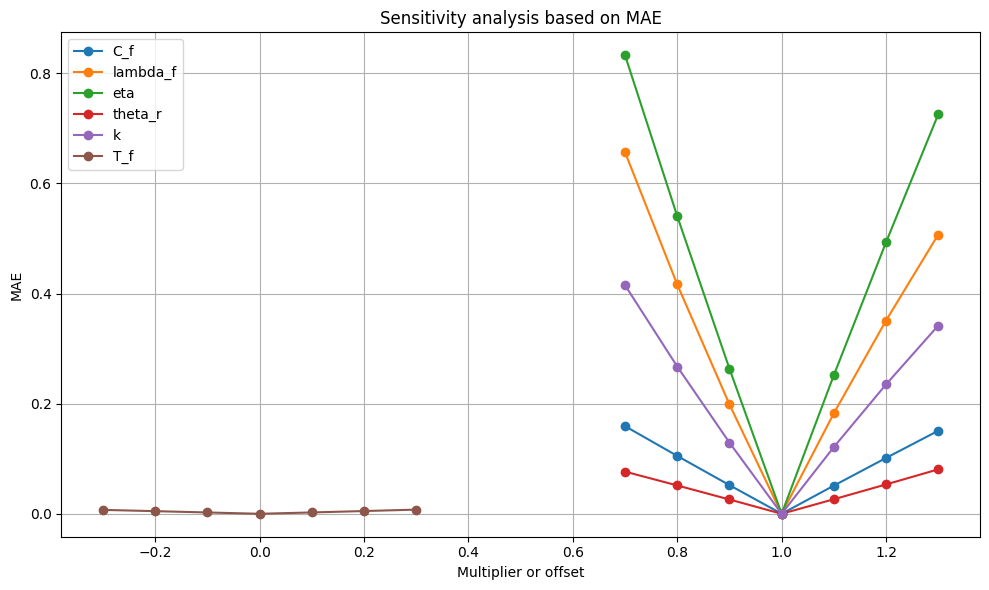

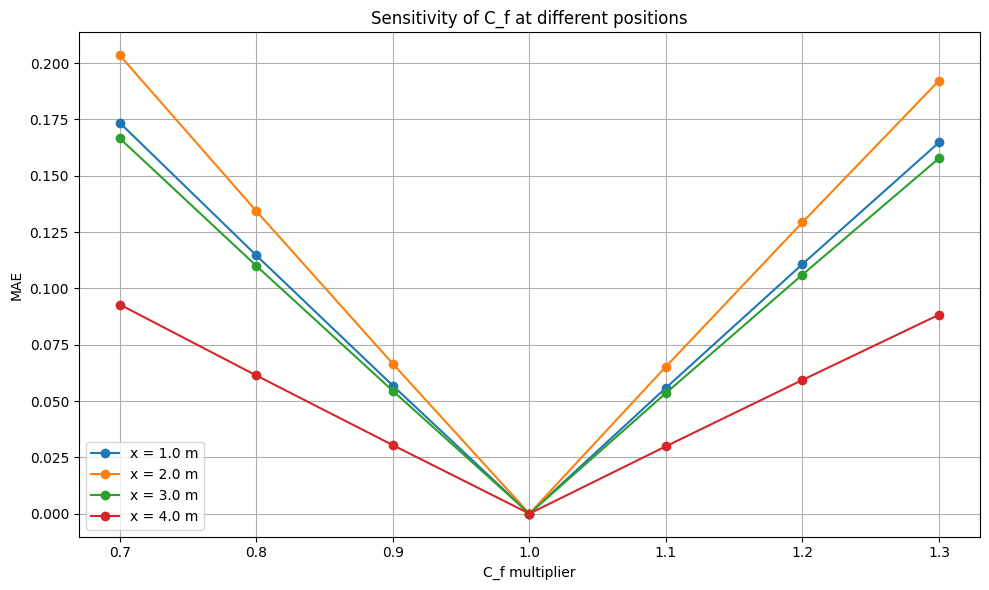

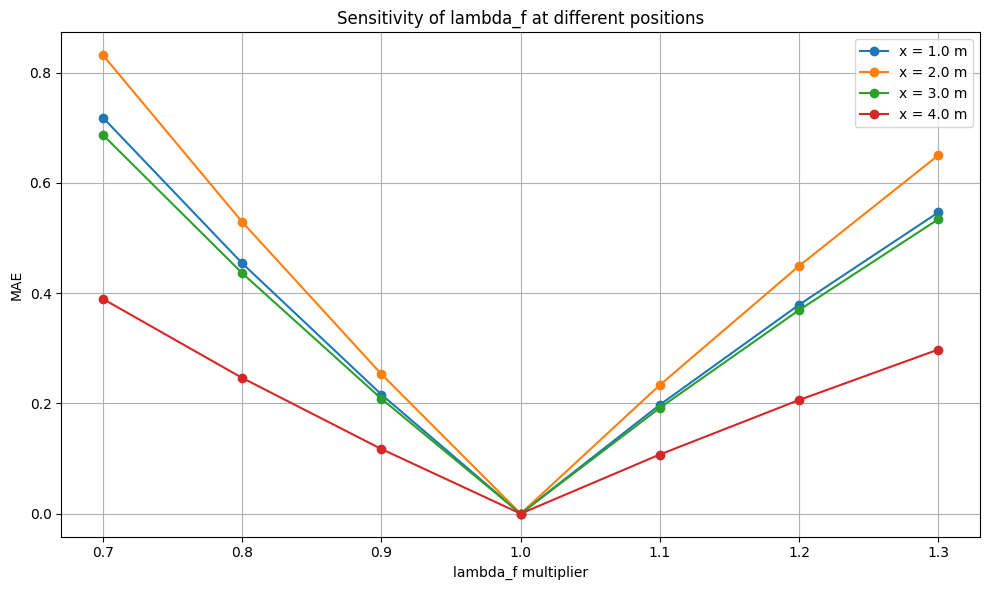

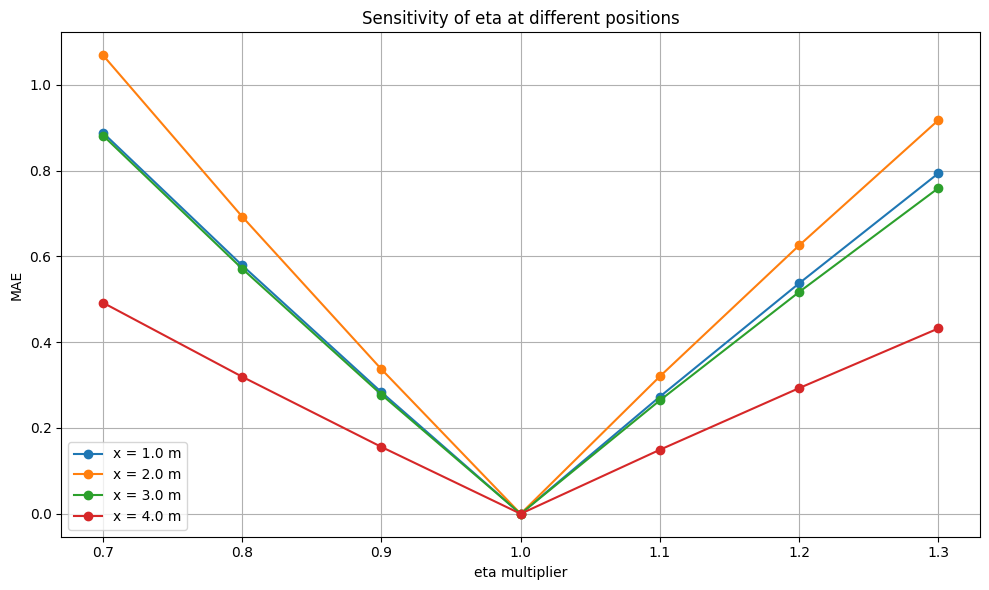

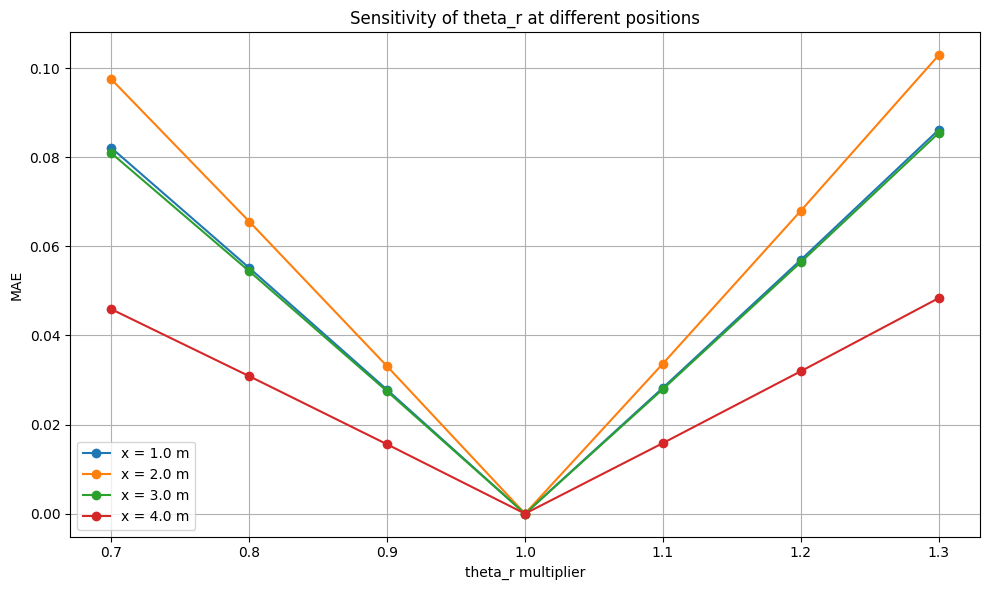

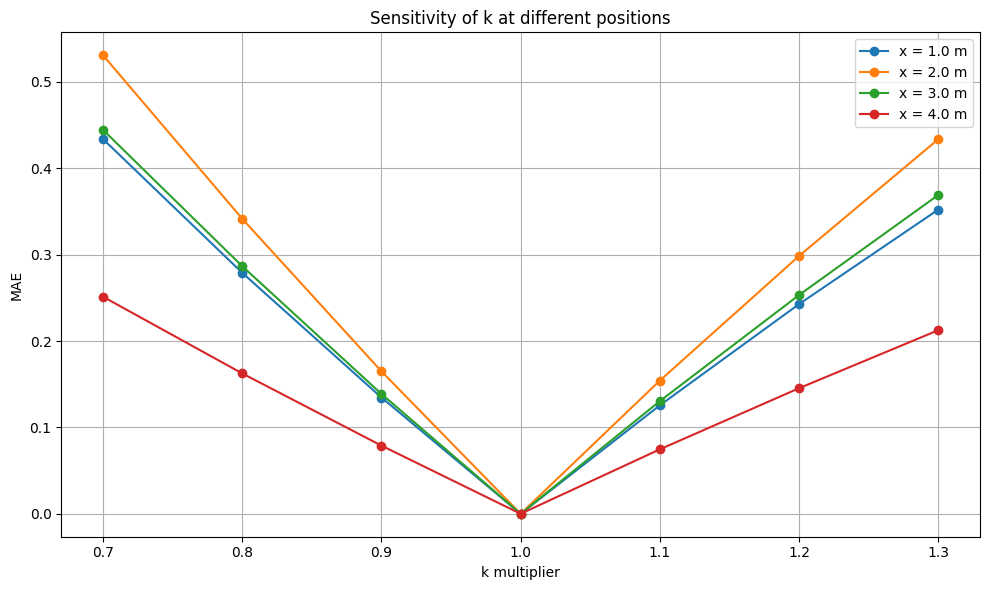

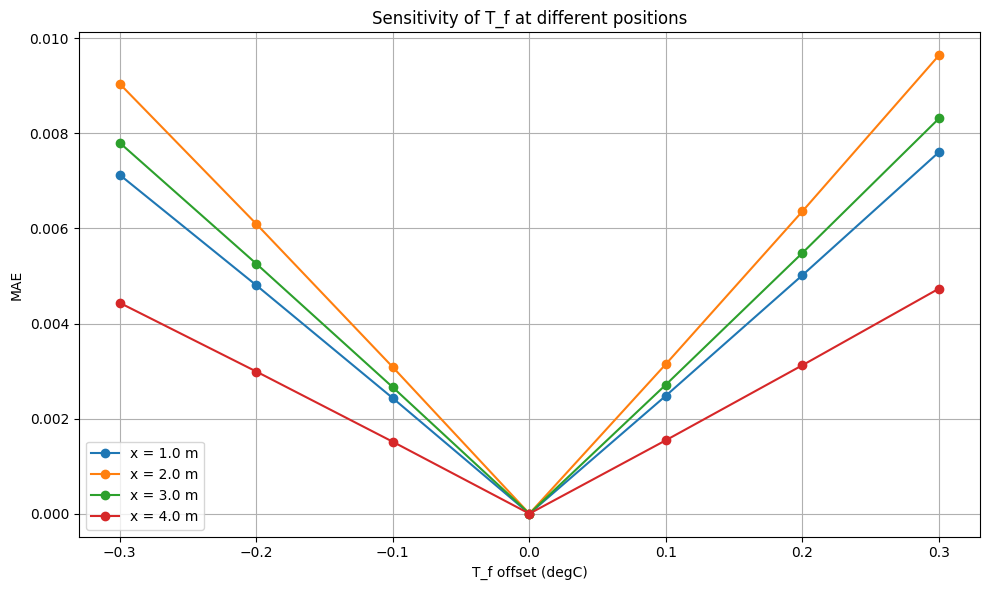

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# =========================================================
# Helper: run FDM
# =========================================================
def run_fdm_model(params, Nx=101, Nt=15000, Lx=5.0, T_total=365.0, verbose=False):
    model = FreezingSoilFDM_LogisticAHC(params)
    model.initialize(Nx=Nx, Nt=Nt, Lx=Lx, T_total=T_total)
    T_field = model.solve_implicit(verbose=verbose)

    x = model.x
    t = model.t

    return x, t, T_field


# =========================================================
# Helper: get nearest indices for observation positions
# =========================================================
def get_obs_indices(x, obs_positions):
    return [np.argmin(np.abs(x - xp)) for xp in obs_positions]


# =========================================================
# Helper: compute MAE
# =========================================================
def compute_mae(T_ref, T_test, obs_indices):
    """
    T_ref, T_test shape: (Nx, Nt)
    obs_indices: spatial indices for observation points

    Returns:
        mae_all: average MAE over all selected positions and all time steps
        mae_each_pos: MAE at each observation position
    """
    T_ref_obs = T_ref[obs_indices, :]   # shape: (Nobs, Nt)
    T_test_obs = T_test[obs_indices, :] # shape: (Nobs, Nt)

    abs_err = np.abs(T_test_obs - T_ref_obs)

    mae_all = np.mean(abs_err)
    mae_each_pos = np.mean(abs_err, axis=1)

    return mae_all, mae_each_pos


# =========================================================
# Sensitivity analysis
# =========================================================
def sensitivity_analysis(
    params_true,
    obs_positions=[1.0, 2.0, 3.0, 4.0],
    ratio_params=['C_f', 'lambda_f', 'eta', 'theta_r', 'k'],
    ratios=np.arange(0.7, 1.31, 0.1),
    tf_offsets=np.array([-0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3]),
    Nx=101,
    Nt=15000,
    Lx=5.0,
    T_total=365.0,
    verbose=False
):
    """
    Perform one-at-a-time sensitivity analysis.

    For ratio_params:
        p_test = ratio * p_true

    For T_f:
        T_f_test = T_f_true + offset
    """

    # -----------------------------
    # Reference solution
    # -----------------------------
    print("Running reference FDM...")
    x, t, T_true = run_fdm_model(
        params_true, Nx=Nx, Nt=Nt, Lx=Lx, T_total=T_total, verbose=verbose
    )

    obs_indices = get_obs_indices(x, obs_positions)

    results = {}

    # -----------------------------
    # Ratio-based parameters
    # -----------------------------
    for pname in ratio_params:
        print(f"Analyzing sensitivity of {pname} ...")

        true_value = params_true[pname]
        results[pname] = {
            "type": "ratio",
            "x_axis": [],
            "param_value": [],
            "mae_all": [],
            "mae_each_pos": []
        }

        for r in ratios:
            params_test = copy.deepcopy(params_true)
            params_test[pname] = true_value * r

            _, _, T_test = run_fdm_model(
                params_test, Nx=Nx, Nt=Nt, Lx=Lx, T_total=T_total, verbose=False
            )

            mae_all, mae_each_pos = compute_mae(T_true, T_test, obs_indices)

            results[pname]["x_axis"].append(r)
            results[pname]["param_value"].append(params_test[pname])
            results[pname]["mae_all"].append(mae_all)
            results[pname]["mae_each_pos"].append(mae_each_pos)

    # -----------------------------
    # T_f with additive perturbation
    # -----------------------------
    print("Analyzing sensitivity of T_f ...")
    tf_true = params_true["T_f"]

    results["T_f"] = {
        "type": "offset",
        "x_axis": [],
        "param_value": [],
        "mae_all": [],
        "mae_each_pos": []
    }

    for dT in tf_offsets:
        params_test = copy.deepcopy(params_true)
        params_test["T_f"] = tf_true + dT

        _, _, T_test = run_fdm_model(
            params_test, Nx=Nx, Nt=Nt, Lx=Lx, T_total=T_total, verbose=False
        )

        mae_all, mae_each_pos = compute_mae(T_true, T_test, obs_indices)

        results["T_f"]["x_axis"].append(dT)
        results["T_f"]["param_value"].append(params_test["T_f"])
        results["T_f"]["mae_all"].append(mae_all)
        results["T_f"]["mae_each_pos"].append(mae_each_pos)

    # Convert lists to arrays
    for pname in results:
        results[pname]["x_axis"] = np.array(results[pname]["x_axis"])
        results[pname]["param_value"] = np.array(results[pname]["param_value"])
        results[pname]["mae_all"] = np.array(results[pname]["mae_all"])
        results[pname]["mae_each_pos"] = np.array(results[pname]["mae_each_pos"])

    return x, t, T_true, obs_indices, results


# =========================================================
# Plot total sensitivity curves
# =========================================================
def plot_total_sensitivity(results):
    plt.figure(figsize=(10, 6))

    for pname, res in results.items():
        plt.plot(res["x_axis"], res["mae_all"], marker='o', label=pname)

    plt.xlabel("Multiplier or offset")
    plt.ylabel("MAE")
    plt.title("Sensitivity analysis based on MAE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# Plot each parameter at each observation position
# =========================================================
def plot_position_sensitivity(results, obs_positions, pname):
    res = results[pname]
    mae_each = res["mae_each_pos"]  # shape: (Ncases, Nobs)

    plt.figure(figsize=(10, 6))
    for i, xp in enumerate(obs_positions):
        plt.plot(res["x_axis"], mae_each[:, i], marker='o', label=f"x = {xp} m")

    if res["type"] == "ratio":
        plt.xlabel(f"{pname} multiplier")
    else:
        plt.xlabel(f"{pname} offset (degC)")

    plt.ylabel("MAE")
    plt.title(f"Sensitivity of {pname} at different positions")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# Print results
# =========================================================
def print_sensitivity_table(results, obs_positions):
    for pname, res in results.items():
        print("\n" + "=" * 70)
        print(f"Parameter: {pname}")
        print("=" * 70)

        if res["type"] == "ratio":
            print(f"{'Multiplier':>12} {'ParamValue':>15} {'MAE_all':>15}", end="")
        else:
            print(f"{'Offset':>12} {'ParamValue':>15} {'MAE_all':>15}", end="")

        for xp in obs_positions:
            print(f" {('MAE@'+str(xp)+'m'):>15}", end="")
        print()

        for i in range(len(res["x_axis"])):
            print(f"{res['x_axis'][i]:12.4f} {res['param_value'][i]:15.6f} {res['mae_all'][i]:15.6f}", end="")
            for j in range(len(obs_positions)):
                print(f" {res['mae_each_pos'][i, j]:15.6f}", end="")
            print()


# =========================================================
# Optional: rank sensitivity
# =========================================================
def rank_parameter_sensitivity(results):
    """
    Use max(MAE_all) as a simple sensitivity indicator.
    """
    sensitivity_score = {}
    for pname, res in results.items():
        sensitivity_score[pname] = np.max(res["mae_all"])

    ranking = sorted(sensitivity_score.items(), key=lambda x: x[1], reverse=True)

    print("\n" + "=" * 70)
    print("Parameter sensitivity ranking (based on max MAE)")
    print("=" * 70)
    for i, (pname, score) in enumerate(ranking, start=1):
        print(f"{i:2d}. {pname:10s}  max_MAE = {score:.6f}")

    return ranking


# =========================================================
# Main
# =========================================================
if __name__ == "__main__":
    params_true = {
        # volumetric latent heat [MJ/m^3]
        'L': 334.0,

        # volumetric heat capacities [MJ/(m^3·K)]
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,

        # thermal conductivities [MJ/(day·m·K)]
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,

        # logistic unfrozen water parameters
        'eta': 0.40,        # porosity [-]
        'theta_r': 0.10,    # residual unfrozen water content [-]
        'T_f': -0.3,        # transition temperature [degC]
        'k': 0.1            # steepness parameter [1/degC]
    }

    obs_positions = [1.0, 2.0, 3.0, 4.0]

    x, t, T_true, obs_indices, results = sensitivity_analysis(
        params_true=params_true,
        obs_positions=obs_positions,
        ratio_params=['C_f', 'lambda_f', 'eta', 'theta_r', 'k'],
        ratios=np.arange(0.7, 1.31, 0.1),
        tf_offsets=np.array([-0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3]),
        Nx=101,
        Nt=15000,
        Lx=5.0,
        T_total=365.0,
        verbose=False
    )

    print("\nObservation positions and nearest grid points:")
    for xp, idx in zip(obs_positions, obs_indices):
        print(f"x_target = {xp:.2f} m, nearest x_grid = {x[idx]:.4f} m, index = {idx}")

    print_sensitivity_table(results, obs_positions)
    rank_parameter_sensitivity(results)

    # Plot overall sensitivity
    plot_total_sensitivity(results)

    # Plot each parameter separately
    for pname in results.keys():
        plot_position_sensitivity(results, obs_positions, pname)

# 2. PINNs Forward Model

Training on device: cuda
Epoch      1 | Total 1.929250e+02 | PDE 5.435626e-07 | IC 4.160470e+01 | BC 1.513202e+02 | DATA 0.000000e+00 | elapsed 0.0s
Epoch   1000 | Total 4.709883e-02 | PDE 2.776404e-04 | IC 1.656157e-03 | BC 1.767863e-02 | DATA 0.000000e+00 | elapsed 26.0s
Epoch   2000 | Total 3.045804e-02 | PDE 6.634456e-05 | IC 6.329244e-03 | BC 1.749434e-02 | DATA 0.000000e+00 | elapsed 52.0s
Epoch   3000 | Total 8.042636e-03 | PDE 3.368645e-05 | IC 6.882554e-04 | BC 3.985736e-03 | DATA 0.000000e+00 | elapsed 78.0s
Epoch   4000 | Total 2.387345e-02 | PDE 2.778828e-05 | IC 7.695816e-03 | BC 1.339881e-02 | DATA 0.000000e+00 | elapsed 104.2s
Epoch   5000 | Total 1.643502e-02 | PDE 1.985094e-05 | IC 5.502721e-03 | BC 8.947209e-03 | DATA 0.000000e+00 | elapsed 130.0s
Epoch   6000 | Total 3.873135e-03 | PDE 1.839474e-05 | IC 2.119796e-04 | BC 1.821681e-03 | DATA 0.000000e+00 | elapsed 155.7s
Epoch   7000 | Total 3.195167e-03 | PDE 1.467089e-05 | IC 5.363995e-04 | BC 1.191678e-03 | DATA 0.

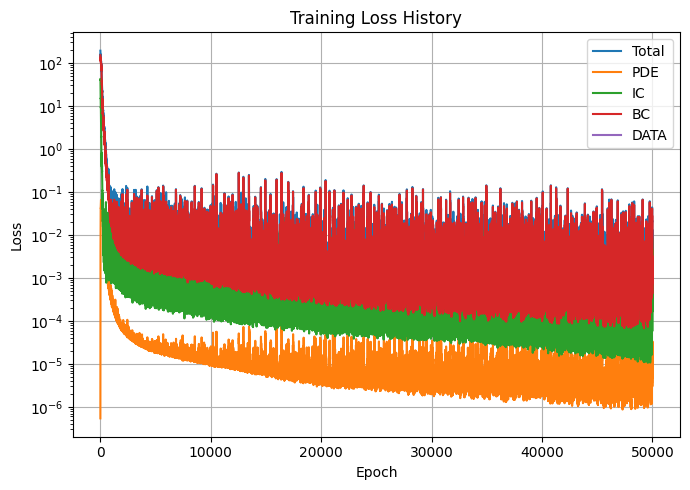

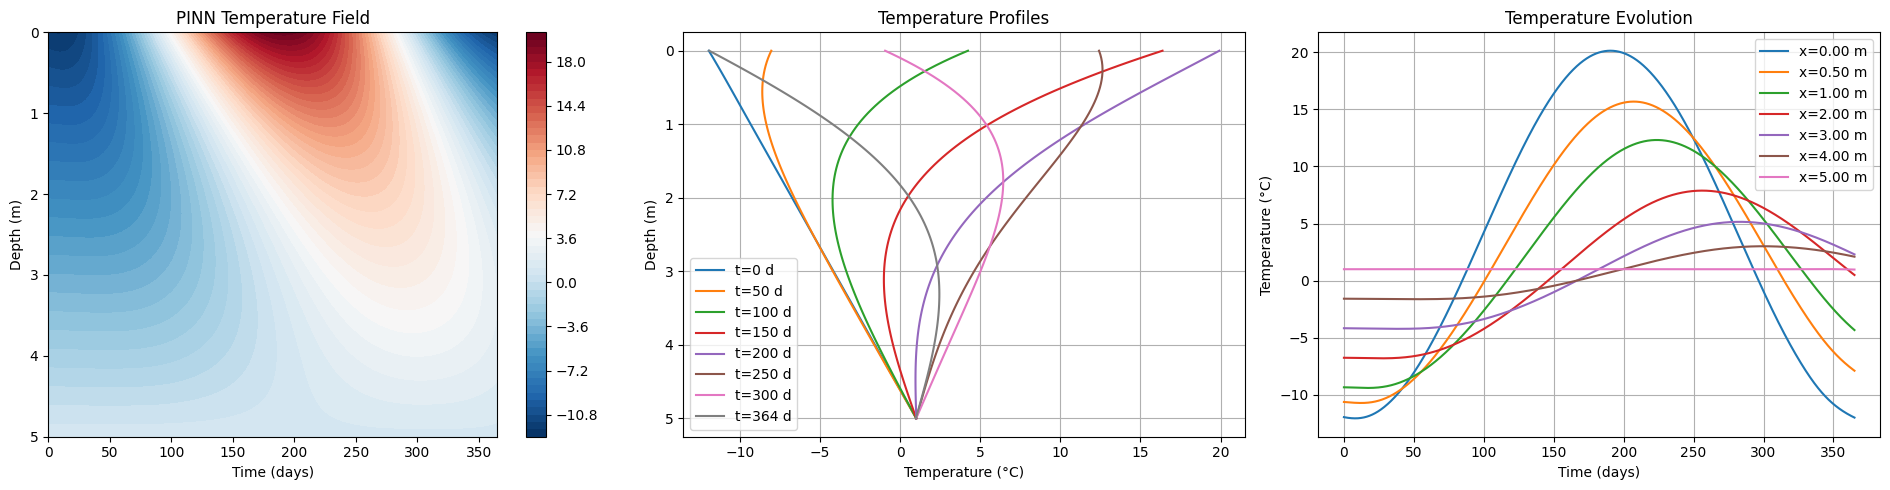

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time


# =========================================================
# Neural network
# =========================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================================================
# PINNs model for freezing/thawing soil
# =========================================================
class FreezingSoilPINN:
    """
    PINNs version corresponding to the uploaded FDM model:
        C_app(T) * dT/dt = d/dx( lambda(T) * dT/dx )

    Expanding the RHS:
        d/dx( lambda(T) * T_x )
        = lambda(T) * T_xx + d(lambda)/dT * (T_x)^2
    so the PDE residual becomes:
        C_app(T) * T_t - lambda(T) * T_xx - lambda_T(T) * (T_x)^2 = 0
    """

    def __init__(self, params, device=None):
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']

        self.eta = params['eta']
        self.theta_r = params['theta_r']
        self.T_f = params['T_f']
        self.k = params['k']

        self.device = device if device is not None else (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.model = MLP(in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5).to(self.device)

        # domain info
        self.Lx = None
        self.T_total = None

        # normalization scales
        self.x_scale = None
        self.t_scale = None

        # history
        self.loss_history = []

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature_np(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def boundary_temperature_torch(self, t):
        return 4.03 + 16.11 * torch.sin(2.0 * torch.pi * t / 365.0 - 1.709)

    def initial_temperature_profile_np(self, x):
        T_surface = self.boundary_temperature_np(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    def initial_temperature_profile_torch(self, x):
        T_surface = self.boundary_temperature_torch(torch.zeros_like(x))
        T_bottom = torch.ones_like(x) * 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + torch.exp(z))

    def dtheta_dT(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        ez = torch.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    def dlambda_dT(self, T):
        """
        lambda(T) = (1-eta) lambda_f + theta lambda_l + (eta-theta) lambda_i
                  = const + theta (lambda_l - lambda_i)
        """
        return (self.lambda_l - self.lambda_i) * self.dtheta_dT(T)

    # =========================================================
    # PINN forward
    # =========================================================
    def net_T(self, x, t):
        """
        Network input uses normalized coordinates:
            x_hat = x / Lx
            t_hat = t / T_total
        """
        x_hat = x / self.x_scale
        t_hat = t / self.t_scale
        inp = torch.cat([x_hat, t_hat], dim=1)
        return self.model(inp)

    # =========================================================
    # PDE residual
    # =========================================================
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.net_T(x, t)

        T_t = torch.autograd.grad(
            T, t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
            retain_graph=True
        )[0]

        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)
        lam_T = self.dlambda_dT(T)

        residual = C_app * T_t - lam * T_xx - lam_T * (T_x ** 2)
        return residual

    # =========================================================
    # Sampling
    # =========================================================
    def sample_collocation(self, N_f):
        x = np.random.rand(N_f, 1) * self.Lx
        t = np.random.rand(N_f, 1) * self.T_total
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device)
        )

    def sample_initial(self, N_i):
        x = np.random.rand(N_i, 1) * self.Lx
        t = np.zeros((N_i, 1))
        T0 = self.initial_temperature_profile_np(x)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T0, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_top(self, N_b):
        x = np.zeros((N_b, 1))
        t = np.random.rand(N_b, 1) * self.T_total
        Tb = self.boundary_temperature_np(t)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(Tb, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_bottom(self, N_b):
        x = np.ones((N_b, 1)) * self.Lx
        t = np.random.rand(N_b, 1) * self.T_total
        Tb = np.ones((N_b, 1)) * 1.0
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(Tb, dtype=torch.float32, device=self.device)
        )

    # =========================================================
    # Optional supervised anchor from FDM
    # =========================================================
    def add_fdm_anchor_data(self, x_data, t_data, T_data):
        """
        Optional:
        use FDM-generated data to force PINN to reproduce FDM more closely.
        x_data, t_data, T_data must be column vectors.
        """
        self.x_data = torch.tensor(x_data, dtype=torch.float32, device=self.device)
        self.t_data = torch.tensor(t_data, dtype=torch.float32, device=self.device)
        self.T_data = torch.tensor(T_data, dtype=torch.float32, device=self.device)

    # =========================================================
    # Loss
    # =========================================================
    def loss_function(
        self,
        N_f=10000,
        N_i=2000,
        N_b=2000,
        w_pde=1.0,
        w_ic=50.0,
        w_bc=50.0,
        w_data=0.0
    ):
        # PDE
        x_f, t_f = self.sample_collocation(N_f)
        res_f = self.pde_residual(x_f, t_f)
        loss_pde = torch.mean(res_f ** 2)

        # Initial condition
        x_i, t_i, T_i_true = self.sample_initial(N_i)
        T_i_pred = self.net_T(x_i, t_i)
        loss_ic = torch.mean((T_i_pred - T_i_true) ** 2)

        # Top boundary
        x_bt, t_bt, T_bt_true = self.sample_boundary_top(N_b)
        T_bt_pred = self.net_T(x_bt, t_bt)
        loss_bc_top = torch.mean((T_bt_pred - T_bt_true) ** 2)

        # Bottom boundary
        x_bb, t_bb, T_bb_true = self.sample_boundary_bottom(N_b)
        T_bb_pred = self.net_T(x_bb, t_bb)
        loss_bc_bottom = torch.mean((T_bb_pred - T_bb_true) ** 2)

        loss_bc = loss_bc_top + loss_bc_bottom

        # Optional data loss
        loss_data = torch.tensor(0.0, device=self.device)
        if hasattr(self, "x_data") and w_data > 0.0:
            T_data_pred = self.net_T(self.x_data, self.t_data)
            loss_data = torch.mean((T_data_pred - self.T_data) ** 2)

        total_loss = (
            w_pde * loss_pde +
            w_ic * loss_ic +
            w_bc * loss_bc +
            w_data * loss_data
        )

        loss_dict = {
            "loss_total": total_loss,
            "loss_pde": loss_pde.detach().item(),
            "loss_ic": loss_ic.detach().item(),
            "loss_bc": loss_bc.detach().item(),
            "loss_data": loss_data.detach().item()
        }

        return total_loss, loss_dict

    # =========================================================
    # Train
    # =========================================================
    def train(
        self,
        Lx=5.0,
        T_total=365.0,
        epochs_adam=10000,
        lr=1e-3,
        N_f=8000,
        N_i=1000,
        N_b=1000,
        w_pde=1.0,
        w_ic=50.0,
        w_bc=50.0,
        w_data=0.0,
        print_every=500,
        use_lbfgs=True
    ):
        self.Lx = Lx
        self.T_total = T_total
        self.x_scale = Lx
        self.t_scale = T_total

        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        start = time.time()
        print(f"Training on device: {self.device}")

        for ep in range(1, epochs_adam + 1):
            optimizer.zero_grad()

            loss, info = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
            )
            loss.backward()
            optimizer.step()

            self.loss_history.append([
                ep,
                info["loss_total"].detach().item(),
                info["loss_pde"],
                info["loss_ic"],
                info["loss_bc"],
                info["loss_data"]
            ])

            if ep % print_every == 0 or ep == 1:
                print(
                    f"Epoch {ep:6d} | "
                    f"Total {info['loss_total'].detach().item():.6e} | "
                    f"PDE {info['loss_pde']:.6e} | "
                    f"IC {info['loss_ic']:.6e} | "
                    f"BC {info['loss_bc']:.6e} | "
                    f"DATA {info['loss_data']:.6e} | "
                    f"elapsed {time.time() - start:.1f}s"
                )

        if use_lbfgs:
            print("Starting L-BFGS refinement...")

            optimizer_lbfgs = torch.optim.LBFGS(
                self.model.parameters(),
                lr=1.0,
                max_iter=500,
                max_eval=500,
                tolerance_grad=1e-9,
                tolerance_change=1e-12,
                history_size=50,
                line_search_fn="strong_wolfe"
            )

            def closure():
                optimizer_lbfgs.zero_grad()
                loss, _ = self.loss_function(
                    N_f=N_f, N_i=N_i, N_b=N_b,
                    w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
                )
                loss.backward()
                return loss

            optimizer_lbfgs.step(closure)

        print(f"Training completed in {time.time() - start:.1f}s")

    # =========================================================
    # Prediction
    # =========================================================
    def predict(self, x, t):
        self.model.eval()
        with torch.no_grad():
            x_ten = torch.tensor(x, dtype=torch.float32, device=self.device)
            t_ten = torch.tensor(t, dtype=torch.float32, device=self.device)
            T_pred = self.net_T(x_ten, t_ten).cpu().numpy()
        return T_pred

    def predict_field(self, Nx=101, Nt=1000):
        x = np.linspace(0.0, self.Lx, Nx)
        t = np.linspace(0.0, self.T_total, Nt)

        X, TT = np.meshgrid(x, t, indexing='ij')
        x_flat = X.reshape(-1, 1)
        t_flat = TT.reshape(-1, 1)

        T_flat = self.predict(x_flat, t_flat)
        T_field = T_flat.reshape(Nx, Nt)

        return x, t, T_field

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self, Nx=101, Nt=1000):
        x, t, T_field = self.predict_field(Nx=Nx, Nt=Nt)

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t, x, T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('PINN Temperature Field')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t - tt))
            axes[1].plot(T_field[:, idx], x, label=f't={t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(x - dd))
            axes[2].plot(t, T_field[idx, :], label=f'x={x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_loss(self):
        hist = np.array(self.loss_history)
        if hist.size == 0:
            print("No training history found.")
            return

        plt.figure(figsize=(7, 5))
        plt.semilogy(hist[:, 0], hist[:, 1], label='Total')
        plt.semilogy(hist[:, 0], hist[:, 2], label='PDE')
        plt.semilogy(hist[:, 0], hist[:, 3], label='IC')
        plt.semilogy(hist[:, 0], hist[:, 4], label='BC')
        plt.semilogy(hist[:, 0], hist[:, 5], label='DATA')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss History")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# =========================================================
# Example main
# =========================================================
if __name__ == "__main__":
    params = {
        # latent heat and volumetric heat capacities
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,

        # conductivities converted to MJ/(day·m·K)
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,

        # logistic unfrozen water parameters
        'eta': 0.40,
        'theta_r': 0.10,
        'T_f': -0.3,
        'k': 0.1
    }

    pinn = FreezingSoilPINN(params)

    pinn.train(
        Lx=5.0,
        T_total=365.0,      # one-year simulation
        epochs_adam=50000,
        lr=1e-3,
        N_f=8000,
        N_i=1000,
        N_b=1000,
        w_pde=100.0,
        w_ic=1.0,
        w_bc=1.0,
        w_data=0.0,         # set > 0 if using FDM anchor data
        print_every=1000,
        use_lbfgs=True
    )

    x_pinn, t_pinn, T_field_pinn = pinn.predict_field(Nx=101, Nt=15000)
    np.savez(
        "pinns_result.npz",
        x_pinn=x_pinn,
        t_pinn=t_pinn,
        T_field_pinn=T_field_pinn
    )
    
    print("Has FDM data supervision:", hasattr(pinn, "x_data"))
    print("PINN T min =", np.min(T_field_pinn))
    print("PINN T max =", np.max(T_field_pinn))
    print("Surface final T =", T_field_pinn[0, -1])
    print("Bottom final T =", T_field_pinn[-1, -1])

    pinn.plot_loss()
    pinn.plot_results(Nx=101, Nt=15000)

In [30]:
import pandas as pd

df = pd.DataFrame(
    pinn.loss_history,
    columns=["epoch", "total", "pde", "ic", "bc", "data"]
)

df.to_csv("loss_history.csv", index=False)
print("Saved: loss_history.csv")

Saved: loss_history.csv


In [19]:
T_field_pinn = T_field_pinn

MAE  = 0.002150614
RMSE = 0.0029781258


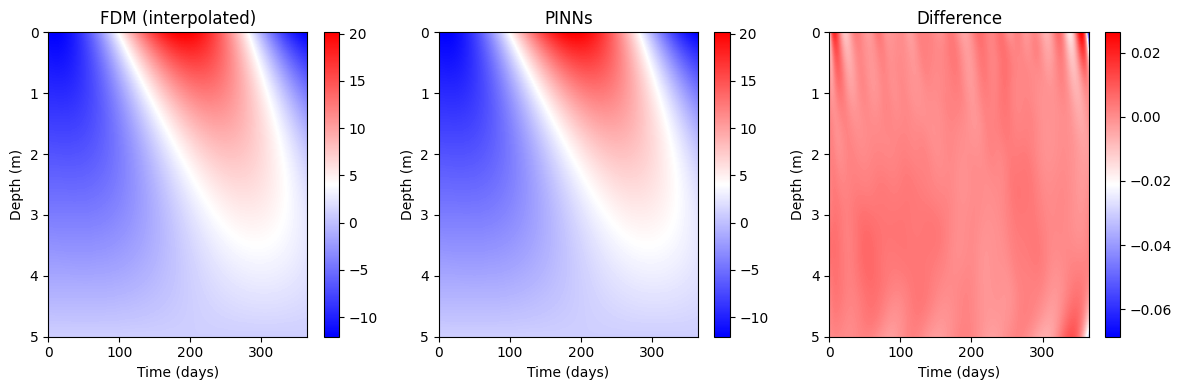

In [21]:
import numpy as np
import matplotlib.pyplot as plt

old_idx = np.linspace(0, 1, T_field_fdm.shape[1])
new_idx = np.linspace(0, 1, T_field_pinn.shape[1])

T_fdm_interp = np.zeros_like(T_field_pinn)
for i in range(T_field_fdm.shape[0]):
    T_fdm_interp[i, :] = np.interp(new_idx, old_idx, T_field_fdm[i, :])

error = T_field_pinn - T_fdm_interp

print("MAE  =", np.mean(np.abs(error)))
print("RMSE =", np.sqrt(np.mean(error**2)))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(T_fdm_interp, aspect='auto', origin='upper', cmap='bwr',
           extent=[0, 365, 5, 0])
plt.title("FDM (interpolated)")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(T_field_pinn, aspect='auto', origin='upper', cmap='bwr',
           extent=[0, 365, 5, 0])
plt.title("PINNs")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(error, aspect='auto', origin='upper', cmap='bwr',
           extent=[0, 365, 5, 0])
plt.title("Difference")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
# save the data

In [24]:
import numpy as np

old_idx = np.linspace(0, 1, T_field_fdm.shape[1])
new_idx = np.linspace(0, 1, T_field_pinn.shape[1])

T_fdm_interp = np.zeros_like(T_field_pinn)
for i in range(T_field_fdm.shape[0]):
    T_fdm_interp[i, :] = np.interp(new_idx, old_idx, T_field_fdm[i, :])

error = T_field_pinn - T_fdm_interp

np.savez(
    "pinn_fdm_results.npz",
    T_field_pinn=T_field_pinn,
    T_fdm_interp=T_fdm_interp,
    error=error
)

print("Saved: pinn_fdm_results.npz")
print("MAE  =", np.mean(np.abs(error)))
print("RMSE =", np.sqrt(np.mean(error**2)))

Saved: pinn_fdm_results.npz
MAE  = 0.002150614
RMSE = 0.0029781258


In [25]:
import numpy as np
from scipy.io import savemat

data = np.load("pinn_fdm_results.npz")

savemat("pinn_fdm_results.mat", {
    "T_field_pinn": data["T_field_pinn"],
    "T_fdm_interp": data["T_fdm_interp"],
    "error": data["error"]
})